# 冻结正式矩阵：结果聚合与深层归因

本 notebook 只读取已接受的 **6 方法 × 6 场景 × 3 训练种子 = 108** 项正式结果，
每项保持 **100,000 raw SUMO steps、10 个 checkpoint、50 个确定性测试回合**。
它不会训练、评估、选择或覆盖任何模型；所有输出均写入本报告目录。

**结论先行：** MST+SLT 的场景等权成功率最高（94.0%）且训练种子内最稳定；
Full+BalancedSlots 未在该冻结协议下改善总体结果，相对 MST+SLT 的成功率宏差为
−13.11 个百分点、碰撞率宏差为 +7.44 个百分点。不过 3 个训练种子使 Holm 校正后的
主指标检验均未达到显著性门槛，因此这些结果是有方向性的预声明消融证据，不是强因果定论。

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

REPORT_DIR = Path.cwd().resolve()
assert (REPORT_DIR / "deep_attribution_analysis.py").is_file(), REPORT_DIR
TABLES = REPORT_DIR / "tables"
OFFICIAL = REPORT_DIR / "official_analysis"
PROJECT_ROOT = REPORT_DIR.parents[1]

METHOD_LABELS = {
    "sac": "SAC", "ppo": "PPO", "mst": "MST", "mst_slt": "MST+SLT",
    "temporal_graph": "TemporalGraph", "full_balanced": "Full+BalancedSlots",
}
SCENARIO_LABELS = {
    "left_turn": "Left turn", "cross": "Cross", "roundabout_easy": "Roundabout easy",
    "roundabout_medium": "Roundabout medium", "roundabout": "Roundabout", "carla": "CARLA",
}
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

## 1. 可复跑的数据质量门槛

下面首先重跑只读伴随审计。它核对矩阵键、协议哈希、评估配对、有限值、100k 时钟、
checkpoint 数量与 CRC/SHA，以及重跑证据归档哈希。任何关键门槛失败都会让命令以非零状态退出。

In [2]:
completed = subprocess.run(
    [
        sys.executable,
        str(REPORT_DIR / "deep_attribution_analysis.py"),
        "--project-root", str(PROJECT_ROOT),
        "--output-dir", str(REPORT_DIR),
    ],
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout)

quality = json.loads((REPORT_DIR / "data_quality_report.json").read_text(encoding="utf-8"))
checks = quality["checks"]
quality_view = pd.DataFrame([
    {"检查": "冻结矩阵", "结果": f"{checks['unique_run_keys']}/108", "状态": "通过"},
    {"检查": "确定性测试回合", "结果": f"{checks['total_test_episodes']}/5400", "状态": "通过"},
    {"检查": "100k 训练时钟", "结果": f"{checks['runs_with_100k_trained_raw_steps']}/108", "状态": "通过"},
    {"检查": "10 checkpoint + CRC/SHA", "结果": f"{checks['runs_with_checkpoint_audit_passed']}/108", "状态": "通过"},
    {"检查": "评估配对错误", "结果": len(checks["evaluation_pairing_errors"]), "状态": "通过"},
    {"检查": "非有限指标", "结果": 108 - checks["runs_with_finite_metrics"], "状态": "通过"},
    {"检查": "成功+超时边界重叠", "结果": f"{checks['success_timeout_overlap_records']}/5400", "状态": "已披露"},
])
display(quality_view)
print("protocol SHA256:", quality["protocol_sha256"])
print("retry archive SHA256:", quality["retry_archive_manifest_sha256"])

{
  "quality_pass": true,
  "runs": 108,
  "episodes": 5400,
  "protocol_sha256": "0CA2FA9E2D2CDC63AF9288AE51210D1B14CF5B95D9A351F874C56BBC7769181A",
  "output_dir": "D:\\Program Files (x86)\\paper\\Scene-Rep-Transformer-main1\\Scene-Rep-Transformer-main\\pytorch_sb3_sumo\\reports\\systematic_matrix_deep_attribution_20260814"
}



,检查,结果,状态
0,冻结矩阵,108/108,通过
1,确定性测试回合,5400/5400,通过
2,100k 训练时钟,108/108,通过
3,10 checkpoint + CRC/SHA,108/108,通过
4,评估配对错误,0,通过
5,非有限指标,0,通过
6,成功+超时边界重叠,2/5400,已披露


protocol SHA256: 0CA2FA9E2D2CDC63AF9288AE51210D1B14CF5B95D9A351F874C56BBC7769181A
retry archive SHA256: 95F44AB0CDBB08794F71E99DB274DFD85A9CCD5146FDC368E1DF06B6C15C1701


2 个记录同时带有 `success=true` 与 `timeout=true`。代码追踪表明评估器在最终 step 独立记录
`is_success` 和 `max_time`，因此“恰好在时限边界到达”是允许的标签重叠。冻结 success/collision
指标不改写；将这 2 个记录保守地仅视为 timeout 的敏感性分析不改变任何预声明对比的符号。
`off_route_rate` 在 108 项中恒为 0，完整但不具区分力。

## 2. 总体排名：MST+SLT 领先且最稳定

所有总体值均先在每个场景内对 3 个训练种子取均值，再对 6 个场景等权平均；
因每格均为 50 回合，当前设计下场景等权宏均值也等于 18 个 run 率的简单均值。

,方法,success_rate_macro_mean,collision_rate_macro_mean,timeout_rate_macro_mean,mean_return_macro_mean,success_rate_mean_scenario_rank,success_rate_scenario_wins_including_ties
3,MST+SLT,94.0%,6.0%,0.0%,0.880,1.83,2
4,TemporalGraph,90.7%,8.8%,0.8%,0.819,2.83,1
2,MST,88.9%,10.7%,0.4%,0.782,2.33,3
5,Full+BalancedSlots,80.9%,13.4%,5.7%,0.674,4.00,1
0,SAC,80.6%,15.0%,4.4%,0.656,4.33,0
1,PPO,50.8%,24.1%,25.1%,0.267,5.67,0


C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:24: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:24: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:24: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:24: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:24: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\3159834529.py:2

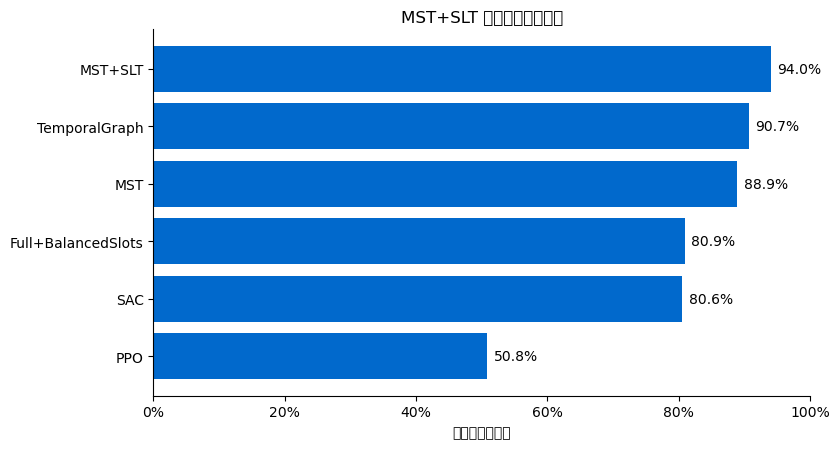

In [3]:
method = pd.read_csv(TABLES / "method_macro_summary.csv")
method["方法"] = method["method"].map(METHOD_LABELS)
ranking = method[[
    "方法", "success_rate_macro_mean", "collision_rate_macro_mean",
    "timeout_rate_macro_mean", "mean_return_macro_mean",
    "success_rate_mean_scenario_rank", "success_rate_scenario_wins_including_ties",
]].sort_values("success_rate_macro_mean", ascending=False)
display(ranking.style.format({
    "success_rate_macro_mean": "{:.1%}", "collision_rate_macro_mean": "{:.1%}",
    "timeout_rate_macro_mean": "{:.1%}", "mean_return_macro_mean": "{:.3f}",
    "success_rate_mean_scenario_rank": "{:.2f}",
}))

plot_data = ranking.sort_values("success_rate_macro_mean")
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(plot_data["方法"], plot_data["success_rate_macro_mean"], color="#0169CC")
ax.set_xlim(0, 1)
ax.set_xlabel("场景等权成功率")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
for i, value in enumerate(plot_data["success_rate_macro_mean"]):
    ax.text(value + 0.01, i, f"{value:.1%}", va="center")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("MST+SLT 的总体成功率最高")
plt.tight_layout()
plt.show()

## 3. 场景异质性：Full+BalancedSlots 的损失集中在中型环岛与 CARLA

仅看总体均值会掩盖重要的场景差异。下表给出 36 个方法×场景单元的成功率；
每格是 3 个训练种子、共 150 个确定性回合的均值。

In [4]:
cells = pd.read_csv(OFFICIAL / "tables" / "cell_metrics.csv")
cells["方法"] = cells["method"].map(METHOD_LABELS)
cells["场景"] = cells["scenario"].map(SCENARIO_LABELS)
scenario_matrix = cells.pivot(index="方法", columns="场景", values="success_rate_mean")
display(scenario_matrix.style.format("{:.1%}").background_gradient(cmap="Blues", vmin=0, vmax=1))

attr = pd.read_csv(TABLES / "scenario_attribution.csv")
full_vs_slt = attr[attr["comparison"].eq("full_balanced_minus_mst_slt")].copy()
full_vs_slt["场景"] = full_vs_slt["scenario"].map(SCENARIO_LABELS)
display(full_vs_slt[[
    "场景", "success_delta", "success_ci_low", "success_ci_high",
    "collision_delta", "collision_ci_low", "collision_ci_high",
    "timeout_delta", "return_delta",
]].style.format({col: "{:+.1%}" for col in [
    "success_delta", "success_ci_low", "success_ci_high", "collision_delta",
    "collision_ci_low", "collision_ci_high", "timeout_delta",
]} | {"return_delta": "{:+.3f}"}))

场景,CARLA,Cross,Left turn,Roundabout,Roundabout easy,Roundabout medium
方法,,,,,,
Full+BalancedSlots,66.7%,77.3%,98.0%,83.3%,94.7%,65.3%
MST,100.0%,78.7%,72.0%,92.7%,96.7%,93.3%
MST+SLT,98.0%,86.7%,97.3%,90.7%,99.3%,92.0%
PPO,10.7%,41.3%,58.7%,38.0%,86.0%,70.0%
SAC,91.3%,37.3%,93.3%,85.3%,92.0%,84.0%
TemporalGraph,100.0%,82.7%,95.3%,81.3%,96.7%,88.0%


,场景,success_delta,success_ci_low,success_ci_high,collision_delta,collision_ci_low,collision_ci_high,timeout_delta,return_delta
24,Left turn,+0.7%,-4.0%,+4.0%,-0.7%,-4.0%,+4.0%,+0.0%,+0.013
25,Cross,-9.3%,-27.3%,+5.3%,+9.3%,-6.0%,+28.0%,+0.0%,-0.187
26,Roundabout easy,-4.7%,-11.3%,+0.0%,+3.3%,-2.0%,+10.7%,+1.3%,-0.080
27,Roundabout medium,-26.7%,-60.0%,-0.7%,+26.7%,+0.7%,+58.7%,+0.0%,-0.533
28,Roundabout,-7.3%,-16.0%,+0.7%,+6.7%,-0.7%,+14.7%,+0.7%,-0.140
29,CARLA,-31.3%,-100.0%,+6.0%,-0.7%,-6.7%,+4.7%,+32.0%,-0.307


Full+BalancedSlots 相对 MST+SLT 的成功率差在 **roundabout_medium 为 −26.67pp**，
在 **CARLA 为 −31.33pp**；left_turn 仅 +0.67pp。中型环岛的分层 bootstrap 95% 区间
已低于 0，但 CARLA 的极端种子离散度使区间仍跨 0。因此更合理的归因是“当前完整组合在特定场景/种子下不稳定”，
而不是把损失单独归因给 topology query 或 balanced slots。

## 4. 预声明消融：只有 MST+SLT−MST 是单组件可识别对比

官方分析使用 10,000 次分层 seed/episode bootstrap、6 场景精确 sign-flip 检验，
并对 5 个 MST 家族主对比分别在 success/collision 上执行 Holm 校正。
PPO−SAC 仅作跨算法家族描述。

,comparison,success_rate_macro_delta,success_rate_scenario_sign_flip_p,success_rate_holm_adjusted_p,collision_rate_macro_delta,collision_rate_scenario_sign_flip_p,collision_rate_holm_adjusted_p,mean_return_macro_delta
0,mst_minus_sac,+8.33%,0.4375,0.7500,-4.33%,0.4062,1.0000,+0.127
1,mst_slt_minus_mst,+5.11%,0.3750,0.7500,-4.67%,0.4375,1.0000,+0.098
2,temporal_graph_minus_mst_slt,-3.33%,0.0938,0.3750,+2.78%,0.1250,0.6250,-0.061
3,full_balanced_minus_temporal_graph,-9.78%,0.2188,0.6562,+4.67%,0.4062,1.0000,-0.144
4,full_balanced_minus_mst_slt,-13.11%,0.0625,0.3125,+7.44%,0.1250,0.6250,-0.206
5,ppo_minus_sac,-29.78%,0.0625,—,+9.11%,0.2500,—,-0.389


C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:33: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:33: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:33: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:33: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:33: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hewenxiang\AppData\Local\Temp\ipykernel_33224\1013250035.py:3

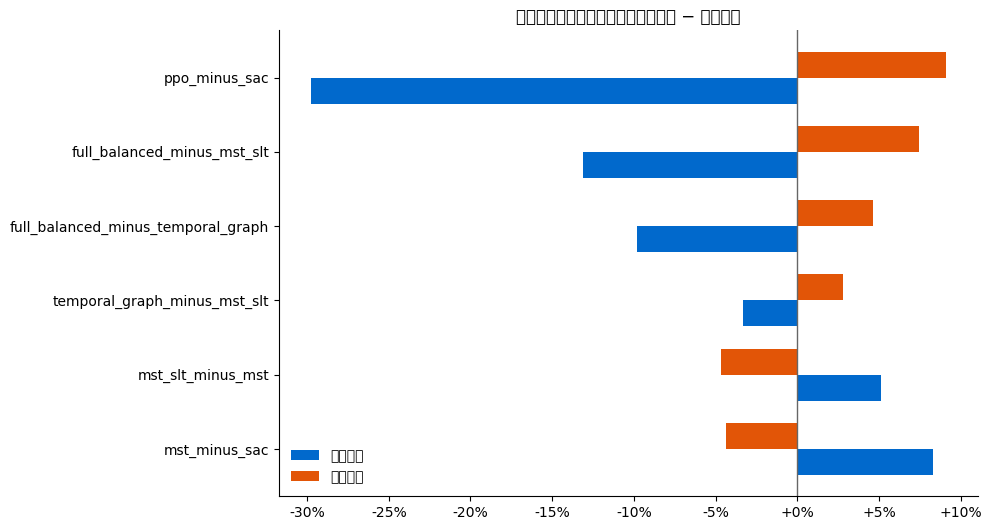

In [5]:
macro = pd.read_csv(OFFICIAL / "tables" / "macro_comparisons.csv")
macro_view = macro[[
    "comparison", "success_rate_macro_delta", "success_rate_scenario_sign_flip_p",
    "success_rate_holm_adjusted_p", "collision_rate_macro_delta",
    "collision_rate_scenario_sign_flip_p", "collision_rate_holm_adjusted_p",
    "mean_return_macro_delta",
]]
display(macro_view.style.format({
    "success_rate_macro_delta": "{:+.2%}", "collision_rate_macro_delta": "{:+.2%}",
    "mean_return_macro_delta": "{:+.3f}", "success_rate_scenario_sign_flip_p": "{:.4f}",
    "success_rate_holm_adjusted_p": "{:.4f}", "collision_rate_scenario_sign_flip_p": "{:.4f}",
    "collision_rate_holm_adjusted_p": "{:.4f}",
}, na_rep="—"))

long = pd.concat([
    macro[["comparison", "success_rate_macro_delta"]].rename(columns={"success_rate_macro_delta": "delta"}).assign(metric="成功率"),
    macro[["comparison", "collision_rate_macro_delta"]].rename(columns={"collision_rate_macro_delta": "delta"}).assign(metric="碰撞率"),
])
fig, ax = plt.subplots(figsize=(10, 5.4))
comparisons = list(macro["comparison"])
y = np.arange(len(comparisons))
width = 0.35
s = macro.set_index("comparison").loc[comparisons, "success_rate_macro_delta"]
c = macro.set_index("comparison").loc[comparisons, "collision_rate_macro_delta"]
ax.barh(y - width / 2, s, height=width, label="成功率差", color="#0169CC")
ax.barh(y + width / 2, c, height=width, label="碰撞率差", color="#E25507")
ax.axvline(0, color="#666", lw=1)
ax.set_yticks(y, comparisons)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:+.0%}")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("预声明对比的场景等权宏差（左方法 − 右方法）")
plt.tight_layout()
plt.show()

MST+SLT−MST 的成功率 +5.11pp、碰撞率 −4.67pp，且 leave-one-scenario-out 后符号保持；
这是最干净的单组件证据。TemporalGraph−MST+SLT 同时改变时序汇聚位置和 Graph-SLT 结构，
Full+BalancedSlots−TemporalGraph 又同时改变 topology query 与 slot normalization；二者都不能拆成单因素效应。
所有 Holm 校正后的主检验均未达到 0.05。

## 5. 稳健性、效率与诊断关联

稳定性采用每个方法在 6 个场景内的“3 训练种子成功率标准差”再平均。
效率来自冻结运行的 `performance_profile.json`，只作观察性成本比较。

In [6]:
stability = pd.read_csv(TABLES / "seed_stability.csv")
stability["方法"] = stability["method"].map(METHOD_LABELS)
display(stability[[
    "方法", "mean_within_scenario_seed_std_success_rate",
    "max_within_scenario_seed_std_success_rate", "max_std_scenario_success_rate",
]].sort_values("mean_within_scenario_seed_std_success_rate").style.format({
    "mean_within_scenario_seed_std_success_rate": "{:.2%}",
    "max_within_scenario_seed_std_success_rate": "{:.2%}",
}))

efficiency = method[[
    "方法", "parameter_count_mean", "wall_ms_per_learner_update_mean",
    "inference_ms_per_action_mean", "peak_gpu_memory_mb_mean",
    "success_rate_macro_mean",
]].copy()
display(efficiency.style.format({
    "parameter_count_mean": "{:,.0f}", "wall_ms_per_learner_update_mean": "{:,.1f}",
    "inference_ms_per_action_mean": "{:.2f}", "peak_gpu_memory_mb_mean": "{:.1f}",
    "success_rate_macro_mean": "{:.1%}",
}))

,方法,mean_within_scenario_seed_std_success_rate,max_within_scenario_seed_std_success_rate,max_std_scenario_success_rate
3,MST+SLT,2.45%,4.32%,roundabout_medium
4,TemporalGraph,3.91%,12.47%,cross
2,MST,7.80%,36.81%,left_turn
0,SAC,9.68%,37.14%,cross
5,Full+BalancedSlots,14.95%,47.14%,carla
1,PPO,21.71%,41.61%,left_turn


,方法,parameter_count_mean,wall_ms_per_learner_update_mean,inference_ms_per_action_mean,peak_gpu_memory_mb_mean,success_rate_macro_mean
0,SAC,"792,872",108.9,6.84,30.6,80.6%
1,PPO,"565,368","4,243.4",8.35,36.9,50.8%
2,MST,"1,086,675",116.5,7.94,103.6,88.9%
3,MST+SLT,"1,270,909",161.1,8.05,109.7,94.0%
4,TemporalGraph,"1,438,248",257.8,13.97,196.9,90.7%
5,Full+BalancedSlots,"2,016,680",379.7,26.11,299.2,80.9%


In [7]:
associations = pd.read_csv(TABLES / "diagnostic_associations.csv")
diagnostic_slice = associations[
    associations["outcome"].eq("success_rate")
    & (
        associations["diagnostic"].isin([
            "diagnostic_topology_attention_entropy_mean",
            "diagnostic_slot_scale_ratio_mean",
            "diagnostic_graph_mean_edge_weight_mean",
        ])
    )
]
display(diagnostic_slice[[
    "association_scope", "method_or_comparison", "diagnostic", "observations",
    "raw_pearson_r", "scenario_residual_pearson_r", "paired_delta_pearson_r",
]].style.format({
    "raw_pearson_r": "{:+.3f}", "scenario_residual_pearson_r": "{:+.3f}",
    "paired_delta_pearson_r": "{:+.3f}",
}, na_rep="—"))

,association_scope,method_or_comparison,diagnostic,observations,raw_pearson_r,scenario_residual_pearson_r,paired_delta_pearson_r
10,within_method,temporal_graph,diagnostic_topology_attention_entropy_mean,18,—,—,—
20,within_method,temporal_graph,diagnostic_slot_scale_ratio_mean,18,+0.383,+0.045,—
22,within_method,temporal_graph,diagnostic_graph_mean_edge_weight_mean,18,-0.265,+0.488,—
34,within_method,full_balanced,diagnostic_topology_attention_entropy_mean,18,-0.366,-0.457,—
44,within_method,full_balanced,diagnostic_slot_scale_ratio_mean,18,+0.212,+0.311,—
46,within_method,full_balanced,diagnostic_graph_mean_edge_weight_mean,18,+0.114,-0.314,—
58,paired_method_delta,full_balanced_minus_temporal_graph,diagnostic_topology_attention_entropy_mean,18,—,—,-0.477
68,paired_method_delta,full_balanced_minus_temporal_graph,diagnostic_slot_scale_ratio_mean,18,—,—,-0.022
70,paired_method_delta,full_balanced_minus_temporal_graph,diagnostic_graph_mean_edge_weight_mean,18,—,—,-0.003


MST+SLT 的平均种子标准差仅 2.45pp；Full+BalancedSlots 为 14.95pp，CARLA 单场景达到 47.14pp。
Full 相比 TemporalGraph 还增加约 40% 参数、47% learner-update 时间、87% 推理时间和 52% 峰值 GPU 内存，
却未带来宏观收益。诊断相关性仅用于提出后续验证假设：例如 Full 内 topology-attention entropy
与场景去均值后的成功率相关为负，而 slot-scale ratio 的关联较弱；18 个 run、共同场景驱动与联合组件变化
均禁止把这些相关性写成机制因果。

## 6. 结论边界与下一步（不修改研究方法）

- 结果表主线应以 **MST+SLT 为当前冻结协议下的最佳、最稳定方法**；Full+BalancedSlots 的完整组合未被支持。
- 唯一可直接归因到单一组件的是 **SLT 相对 MST** 的增益方向；TemporalGraph 与 Full 对比必须保持联合改动措辞。
- 当前阶段可继续做：论文表格/图、逐场景叙述、失败案例索引、统计功效与新增种子预算评估；这些都不应回写或筛选现有结果。
- 若未来要区分 topology query 与 balanced slots，必须另立预注册的正交消融，而不能从本矩阵事后拆解。

本 notebook 的数字来源为冻结结果 JSON、官方聚合器输出和只读伴随审计；技术报告是唯一读者版报告界面。